Convertir datos `raw` en arrays `processed` reutilizables.

Este notebook lee `config/data.toml`, aplica opcionalmente anomalías y eliminación de tendencia Theil-Sen, guarda los arrays finales y los productos necesarios para reconstrucción.


Importa dependencias y utilidades del proyecto.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

import src.data.io as io
import src.data.preprocess as preprocess
from src.data.eda import load_processed_dataset
from src.project_config import resolve_data_config


Carga la configuración de datos y deriva la identidad del run procesado.


In [2]:
cfg = resolve_data_config("../config/data.toml")

raw_dir = cfg["raw_dir"]
mask_dir = cfg["mask_dir"]
VARIABLE_NAMES = cfg["variable_names"]
temporal_resolution = cfg["temporal_resolution"]
data_value_type = cfg["data_value_type"]
detrend_theil_sen = cfg["detrend_theil_sen"]
start_year = cfg["start_year"]
end_year_inclusive = cfg["end_year_inclusive"]
dtype = cfg["dtype"]
roi = cfg["roi"]
mask_names = cfg["mask_names"]
run_name = cfg["run_name"]
output_dir = cfg["output_dir"]
example_var = cfg["target_name"]

expected_run_config = io.build_processed_run_config(
    variable_names=VARIABLE_NAMES,
    temporal_resolution=temporal_resolution,
    mask_names=mask_names,
    start_year=start_year,
    end_year_inclusive=end_year_inclusive,
    dtype=dtype,
    roi=roi,
    data_value_type=data_value_type,
    detrend_theil_sen=detrend_theil_sen,
)

print("run_name:", run_name)
print("output_dir:", output_dir)
print("mask_names:", mask_names if mask_names else ["nomask"])
print("temporal_resolution:", temporal_resolution)
print("data_value_type:", data_value_type)
print("detrend_theil_sen:", detrend_theil_sen)
print("period:", f"{start_year}-{end_year_inclusive}")
print("variable_names:", VARIABLE_NAMES)


run_name: land_monthly_anomaly
output_dir: /home/dani/github/profecia/data/processed/land_monthly_anomaly
mask_names: ['land']
temporal_resolution: monthly
data_value_type: anomaly
detrend_theil_sen: False
period: 1982-2022
variable_names: ['LAI', 'SM1', 'SM2', 'TP', 'T2M', 'SSRD', 'VPD', 'D2M', 'PEV']


Comprueba si el dataset procesado ya existe y coincide con la configuración actual.


In [3]:
processed_status = io.processed_run_status(
    output_dir=output_dir,
    variable_names=VARIABLE_NAMES,
    expected_config=expected_run_config,
)
process_required = not (processed_status["complete"] and processed_status["config_matches"])

print(json.dumps(processed_status, indent=2, ensure_ascii=False))
if process_required:
    print("El run no existe completo o no coincide con la configuración actual. Se procesará.")
else:
    print("El run ya existe y coincide con la configuración actual.")
    print("Ruta:", output_dir)


{
  "output_dir": "/home/dani/github/profecia/data/processed/land_monthly_anomaly",
  "exists": false,
  "complete": false,
  "files_present": false,
  "metadata_present": false,
  "run_config_present": false,
  "config_matches": false,
  "saved_config": null,
  "missing_files": [
    "/home/dani/github/profecia/data/processed/land_monthly_anomaly/LAI.npy",
    "/home/dani/github/profecia/data/processed/land_monthly_anomaly/SM1.npy",
    "/home/dani/github/profecia/data/processed/land_monthly_anomaly/SM2.npy",
    "/home/dani/github/profecia/data/processed/land_monthly_anomaly/TP.npy",
    "/home/dani/github/profecia/data/processed/land_monthly_anomaly/T2M.npy",
    "/home/dani/github/profecia/data/processed/land_monthly_anomaly/SSRD.npy",
    "/home/dani/github/profecia/data/processed/land_monthly_anomaly/VPD.npy",
    "/home/dani/github/profecia/data/processed/land_monthly_anomaly/D2M.npy",
    "/home/dani/github/profecia/data/processed/land_monthly_anomaly/PEV.npy"
  ],
  "metadata_

Carga una variable de referencia y las máscaras activas para validar el grid de entrada.


In [4]:
example_raw, _ = io.load_netcdf(
    base_dir=raw_dir,
    variable=example_var,
    roi=roi,
    start_year=start_year,
    end_year_inclusive=end_year_inclusive,
    dtype=dtype,
)

latitude = example_raw["latitude"].values
longitude = example_raw["longitude"].values
masks = {name: io.load_mask(mask_dir, name, latitude, longitude) for name in mask_names}
combined_mask, mask_info = io.build_combined_filter_mask(example_raw, masks if masks else None)

print("Grid:")
print("  latitude:", float(latitude.min()), "->", float(latitude.max()), "|", len(latitude))
print("  longitude:", float(longitude.min()), "->", float(longitude.max()), "|", len(longitude))
print("  time:", str(example_raw.time.values[0])[:10], "->", str(example_raw.time.values[-1])[:10])
print("Máscaras cargadas:", list(masks.keys()))
print("Mask info:", mask_info)


Grid:
  latitude: -90.0 -> 89.5 | 360
  longitude: -180.0 -> 179.5 | 720
  time: 1982-01-01 -> 2022-12-01
Máscaras cargadas: ['land']
Mask info: {'mask_names': ['land'], 'combined_pixels_kept': 62665, 'combined_total_pixels': 259200, 'combined_fraction_kept': 0.2417631172839506}


Funciones auxiliares para visualizar mapas y series temporales en las celdas de ejemplo.


In [5]:
def spatial_mean_timeseries(da):
    return da.mean(dim=("latitude", "longitude"), skipna=True)


def plot_map_and_series(da, title, time_index=0):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    da.isel(time=time_index).plot(ax=axes[0], robust=True)
    axes[0].set_title(f"{title} | {str(da.time.values[time_index])[:10]}")
    spatial_mean_timeseries(da).plot(ax=axes[1])
    axes[1].set_title(f"{title} | media espacial")
    axes[1].set_xlabel("time")
    fig.tight_layout()
    plt.show()


Prepara una muestra ligera de la variable de referencia para visualizar los pasos opcionales sin recalcular Theil-Sen sobre todo el globo dentro del notebook.

El procesado real de todas las variables se ejecuta más abajo con `io.load_and_save_variable(...)`.


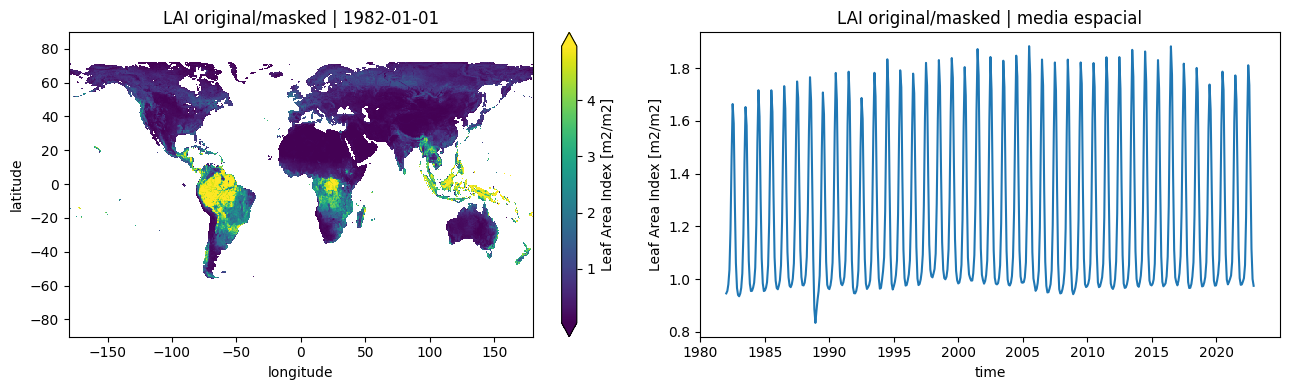

In [15]:
example_agg = io.aggregate_time(
    example_raw,
    variable_name=example_var,
    temporal_resolution=temporal_resolution,
)
example_masked = io.apply_filter_mask(example_agg, combined_mask)

# Muestra espacial para plots interactivos. No afecta al procesado guardado.
plot_stride = 1
example_preview = example_masked.isel(
    latitude=slice(None, None, plot_stride),
    longitude=slice(None, None, plot_stride),
)

plot_map_and_series(example_preview, f"{example_var} original/masked")


Paso opcional 1: calcular anomalías restando climatología.

Si `data_value_type = "anomaly"`, se calcula y se muestra la anomalía de la variable de ejemplo. Si está en `"real"`, este paso no modifica la señal.


Climatology dims: ('month', 'latitude', 'longitude') (12, 360, 720)


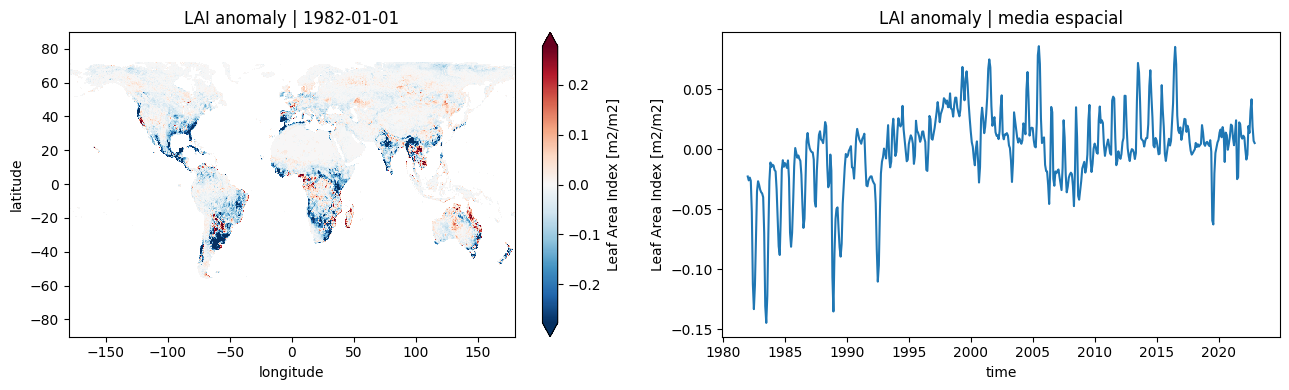

In [16]:
if data_value_type == "anomaly":
    example_climatology = preprocess.calculate_climatology(example_preview, temporal_resolution)
    example_after_anomaly = preprocess.calculate_anomaly(example_preview, example_climatology, temporal_resolution)
    print("Climatology dims:", example_climatology.dims, example_climatology.shape)
    plot_map_and_series(example_after_anomaly, f"{example_var} anomaly")
else:
    example_climatology = None
    example_after_anomaly = example_preview
    print("data_value_type='real': no se calculan anomalías.")


Paso opcional 2: eliminar tendencia temporal con Theil-Sen.

La pendiente se calcula por píxel. En esta vista previa se usa la muestra espacial definida arriba para que la celda sea ligera; el procesado real se hace después sobre todas las variables y todos los píxeles válidos.


In [17]:
if detrend_theil_sen:
    example_after_detrend, example_trend_components = preprocess.remove_theil_sen_trend(example_after_anomaly)
    print("Trend slope dims:", example_trend_components["slope"].dims, example_trend_components["slope"].shape)
    plot_map_and_series(example_after_detrend, f"{example_var} detrended")
else:
    example_trend_components = None
    example_after_detrend = example_after_anomaly
    print("detrend_theil_sen=false: no se elimina tendencia.")


detrend_theil_sen=false: no se elimina tendencia.


Ejecuta el procesado completo de todas las variables configuradas y guarda los arrays finales `.npy`.

Los productos de reconstrucción (`climatology`, `anomaly`, `detrended_anomaly`, `trend_slope`, `trend_time_years_centered`) se guardan en subdirectorios dentro de `output_dir/preprocess/<VARIABLE>/` cuando corresponda.


In [ ]:
results = {}

if process_required:
    output_dir.mkdir(parents=True, exist_ok=True)
    for var in VARIABLE_NAMES:
        print(f"Procesando {var} ...")
        var_result = io.load_and_save_variable(
            raw_dir=raw_dir,
            output_dir=output_dir,
            variable=var,
            mask_dir=mask_dir,
            mask_names=mask_names,
            roi=roi,
            start_year=start_year,
            end_year_inclusive=end_year_inclusive,
            dtype=dtype,
            temporal_resolution=temporal_resolution,
            data_value_type=data_value_type,
            detrend_theil_sen=detrend_theil_sen,
            save_output=True,
        )
        results.update(var_result)
else:
    print("No se reprocesa nada.")

list(results)


Procesando LAI ...
Procesando SM1 ...


Guarda `metadata.json` y `run_config.json` actualizados con los campos de preprocesado y reconstrucción.


In [10]:
if process_required:
    io.save_processed_metadata(
        output_dir=output_dir,
        variable_results=results,
        temporal_resolution=temporal_resolution,
        roi=roi,
        start_year=start_year,
        end_year_inclusive=end_year_inclusive,
        dtype=dtype,
        data_value_type=data_value_type,
        detrend_theil_sen=detrend_theil_sen,
    )
    io.save_metadata_json(output_dir, expected_run_config, filename="run_config.json")
    print("metadata.json guardado en:", output_dir / "metadata.json")
    print("run_config.json guardado en:", output_dir / "run_config.json")
else:
    print("Se mantienen los metadatos existentes en:", output_dir)


metadata.json guardado en: /home/dani/github/profecia/data/processed/land_monthly_anomaly/metadata.json
run_config.json guardado en: /home/dani/github/profecia/data/processed/land_monthly_anomaly/run_config.json


Carga el dataset procesado guardado y visualiza la señal final usada por el modelo.


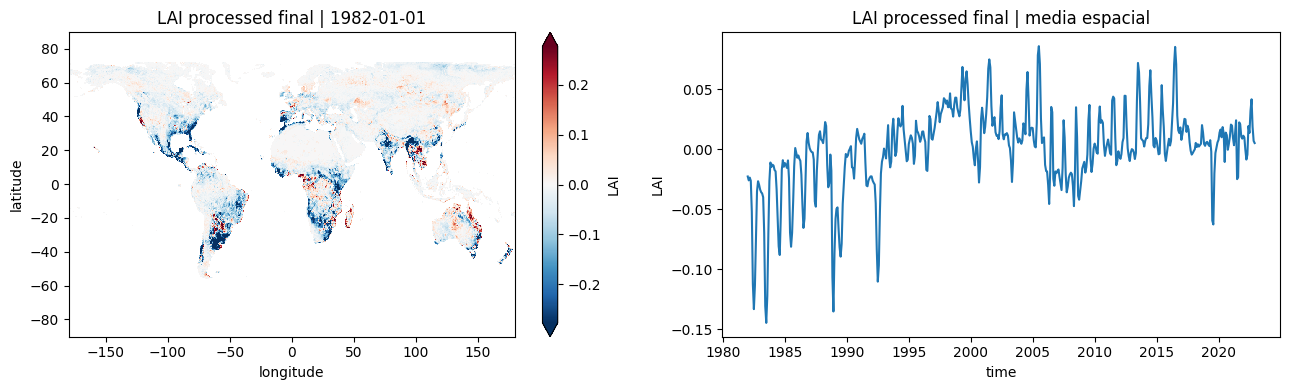

In [11]:
data_dict, processed_metadata = load_processed_dataset(
    input_dir=output_dir,
    variable_names=VARIABLE_NAMES,
    reference_variable=example_var,
)
processed_example = data_dict[example_var]
plot_map_and_series(processed_example, f"{example_var} processed final")


Ejemplo de reconstrucción: lee `metadata.json`, localiza los productos auxiliares guardados y reconstruye la señal original de la variable de ejemplo.


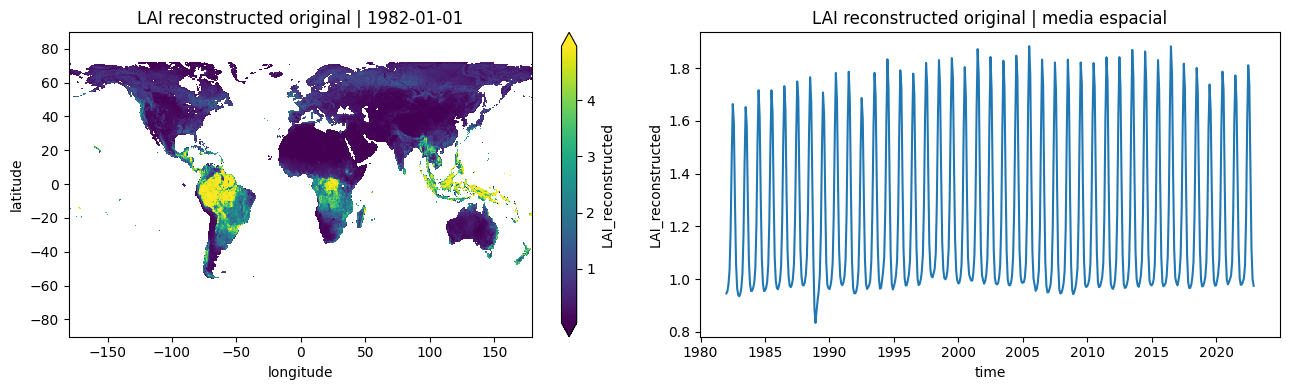

In [12]:
metadata_path = output_dir / "metadata.json"
reconstructed_example = preprocess.reconstruct_original_signal(
    metadata_path=metadata_path,
    variable_name=example_var,
)
plot_map_and_series(reconstructed_example, f"{example_var} reconstructed original")


Compara la reconstrucción con la señal original agregada y enmascarada para comprobar que la inversión es precisa.


max abs diff: 2.384185791015625e-07


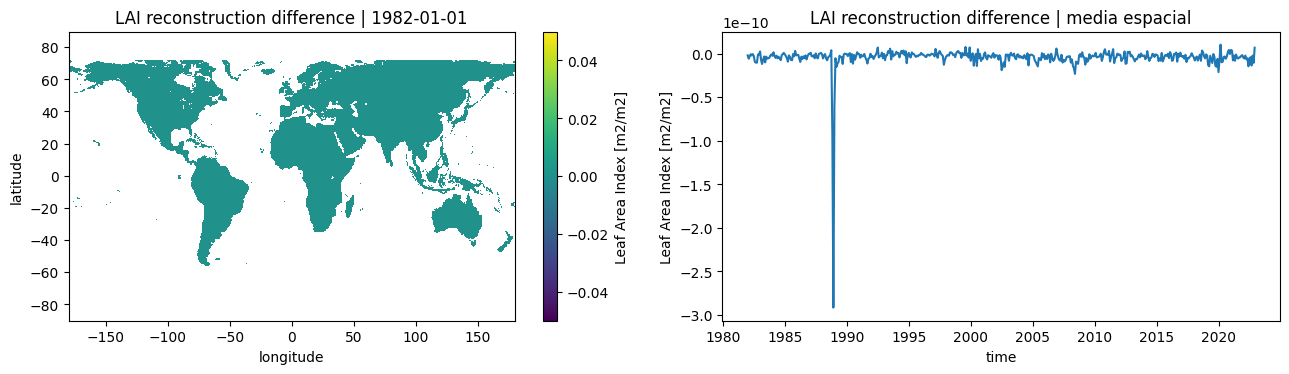

In [13]:
original_for_comparison = example_masked
if original_for_comparison.shape == reconstructed_example.shape:
    diff = reconstructed_example - original_for_comparison
    print("max abs diff:", float(np.nanmax(np.abs(diff.values))))
    plot_map_and_series(diff, f"{example_var} reconstruction difference")
else:
    print("No se compara: shapes diferentes", original_for_comparison.shape, reconstructed_example.shape)


Resumen de rutas finales esperadas.


In [14]:
print("Output dir:", output_dir)
for var in VARIABLE_NAMES:
    print(f"- {var}:", output_dir / f"{var}.npy")

metadata_path = output_dir / "metadata.json"
if metadata_path.exists():
    with open(metadata_path, encoding="utf-8") as f:
        metadata = json.load(f)
    processing = metadata["variables"][example_var]["processing"]
    print("Productos de preprocesado para", example_var)
    print(json.dumps(processing.get("preprocess_products", {}), indent=2, ensure_ascii=False))


Output dir: /home/dani/github/profecia/data/processed/land_monthly_anomaly
- LAI: /home/dani/github/profecia/data/processed/land_monthly_anomaly/LAI.npy
- SM1: /home/dani/github/profecia/data/processed/land_monthly_anomaly/SM1.npy
- SM2: /home/dani/github/profecia/data/processed/land_monthly_anomaly/SM2.npy
- TP: /home/dani/github/profecia/data/processed/land_monthly_anomaly/TP.npy
- T2M: /home/dani/github/profecia/data/processed/land_monthly_anomaly/T2M.npy
- SSRD: /home/dani/github/profecia/data/processed/land_monthly_anomaly/SSRD.npy
- VPD: /home/dani/github/profecia/data/processed/land_monthly_anomaly/VPD.npy
- D2M: /home/dani/github/profecia/data/processed/land_monthly_anomaly/D2M.npy
- PEV: /home/dani/github/profecia/data/processed/land_monthly_anomaly/PEV.npy
Productos de preprocesado para LAI
{
  "climatology": {
    "path": "/home/dani/github/profecia/data/processed/land_monthly_anomaly/preprocess/LAI/climatology.npy",
    "shape": [
      12,
      360,
      720
    ],
    "